# Построение нейросетевого классификатора для идентификации типа подстилающей поверхности при движении мобильного робота в условиях неоднородной среды

Цель работы:
- Приобретение практических навыков в решении одной из актуальных задач в построении
интеллектуальной СУ автономной робототехнической системы, функционирующей в условиях
физически неоднородной среды;
- Практическое изучение особенностей и способов решения задачи несбалансированной
классификации, а также расширение инструментария разработчика в части работы с методами
машинного обучения;
- Развитие исследовательских навыков работы с методом машинного обучения на примере
прикладной задачи и реальной выборке данных;
- Развитие навыков программирования систем вычислительного интеллекта на Python.

In [1]:
import pandas as pd
import seaborn as sns
import openpyxl
import matplotlib.pyplot as plt

# Чтение XLSX файла
file_path = "Data_Set_(A+B).xlsx"

df = pd.read_excel(file_path, engine='openpyxl')

print("Названия параметров (колонок):")
print(df.columns.tolist())

# По заданию нужно определять поверхность 5, для бинарной классификации поверхность 5 будет обозначаться как "1", а остальные - "0".
df['Type'] = df['Type'].apply(lambda x: 1 if x == 5 else 0)

Названия параметров (колонок):
['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3', 'Type']


Далее необходимо добавить параметры, необходимые по заданию

In [2]:
import numpy as np
import pandas as pd

# Расчет vx, vy, omega
vx = (4 * (df['V3real'] + df['V1real']) * np.cos(np.radians(30))) / 15
vy = (4 * (df['V3real'] + df['V1real']) * np.sin(np.radians(30)) - 4 * df['V2real']) / 15
omega = (df['V1real'] + df['V2real'] + df['V3real']) / 6

# Расчет Ix, Iy, Iphi
Ix = (2 * (df['I1'] + df['I3']) * np.cos(np.radians(30))) / 3
Iy = (2 * (df['I1'] + df['I3']) * np.sin(np.radians(30)) - 2 * df['I2']) / 15
Iphi = (df['I1'] + df['I2'] + df['I3']) / 3
Isum = Ix + Iy + Iphi

Tx = vx / Ix
Ty = vy / Iy
Tz = omega / Iphi

# Добавление рассчитанных параметров в DataFrame
df['vx'] = vx
df['vy'] = vy
df['omega'] = omega
df['Ix'] = Ix
df['Iy'] = Iy
df['Iphi'] = Iphi
df['Isum'] = Isum
df['Tx'] = Tx
df['Ty'] = Ty
df['Tz'] = Tz

# После расчета параметров сохраняем обучающую таблицу
output_file_train = "A+B_extended.csv"
df.to_csv(output_file_train, index=False, encoding='utf-8')

file_path = "A+B_extended.csv"
df = pd.read_csv(file_path, encoding='utf-8')

print("Названия параметров (колонок):")
print(df.columns.tolist())

Названия параметров (колонок):
['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3', 'Type', 'vx', 'vy', 'omega', 'Ix', 'Iy', 'Iphi', 'Isum', 'Tx', 'Ty', 'Tz']


Строится тепловая карта и графики, чтобы посмотреть, все ли данные необходимо оставить

In [ ]:
# Построение тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=False,  # показывать значения
            cmap='coolwarm',  # цветовая схема
            center=0,  # центр цветовой шкалы
            fmt='.2f',  # формат чисел
            square=True,  # квадратные ячейки
            linewidths=0.5)  # линии между ячейками

plt.tight_layout()
plt.show()

In [ ]:
# Выбираем только числовые колонки
numeric_columns = df.select_dtypes(include=['number']).columns

# Создаем отдельный график для каждой величины
num_plots = len(numeric_columns)
fig, axes = plt.subplots(num_plots, 1, figsize=(12, 5 * num_plots))

if num_plots == 1:
    axes = [axes]

for i, col in enumerate(numeric_columns):
    axes[i].plot(df.index, df[col], marker='o', linestyle='-', markersize=3, linewidth=1)
    axes[i].set_title(f'График величины: {col}', fontsize=14)
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

По графикам видно, что столбцы N1, N2, N3 повторяют w1,w2,w3. Принято решение оставить только скорости, а обороты удалить.

In [5]:
df = df.drop(['N1', 'N2', 'N3'], axis=1)

Можно обучать модель

In [73]:
def stratified_shuffle(x, y, random_state=None):
    # Устанавливаем random seed
    if random_state is not None:
        np.random.seed(random_state)

    # Преобразуем в списки для удобной работы
    if hasattr(x, 'values'):
        x = x.values.tolist()
    if hasattr(y, 'values'):
        y = y.values.tolist()

    # Получаем уникальные классы
    unique_classes = np.unique(y)

    shuffled_indices = []

    # Для каждого класса
    for class_label in unique_classes:
        # Находим индексы объектов этого класса
        class_indices = [i for i, label in enumerate(y) if label == class_label]
        n_class = len(class_indices)

        # Перемешиваем индексы объектов этого класса
        np.random.shuffle(class_indices)
        shuffled_indices.extend(class_indices)

    # Применяем индексы к x и y
    x_shuffled = [x[i] for i in shuffled_indices]
    y_shuffled = [y[i] for i in shuffled_indices]

    return x_shuffled, y_shuffled

In [74]:
x = df.drop('Type', axis=1)  # все признаки
y = df['Type']  # целевая переменная

# x, y = stratified_shuffle(x, y, random_state=42)


Accuracy по fold'ам: [0.8421 0.8772 0.9107 0.9821 0.9464]
Средняя Accuracy: 0.9117

F1-score по fold'ам: [0.8657 0.8923 0.918  0.9825 0.9474]
Средний F1-score: 0.9212


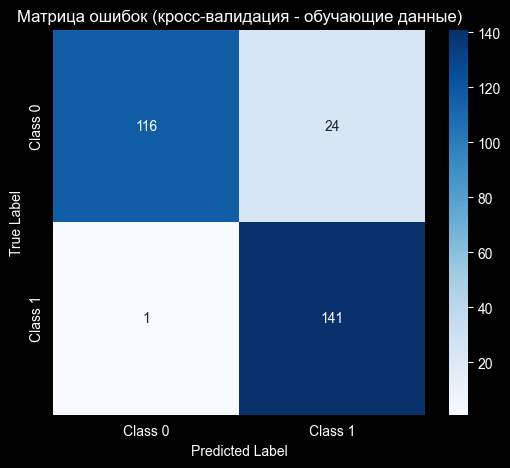

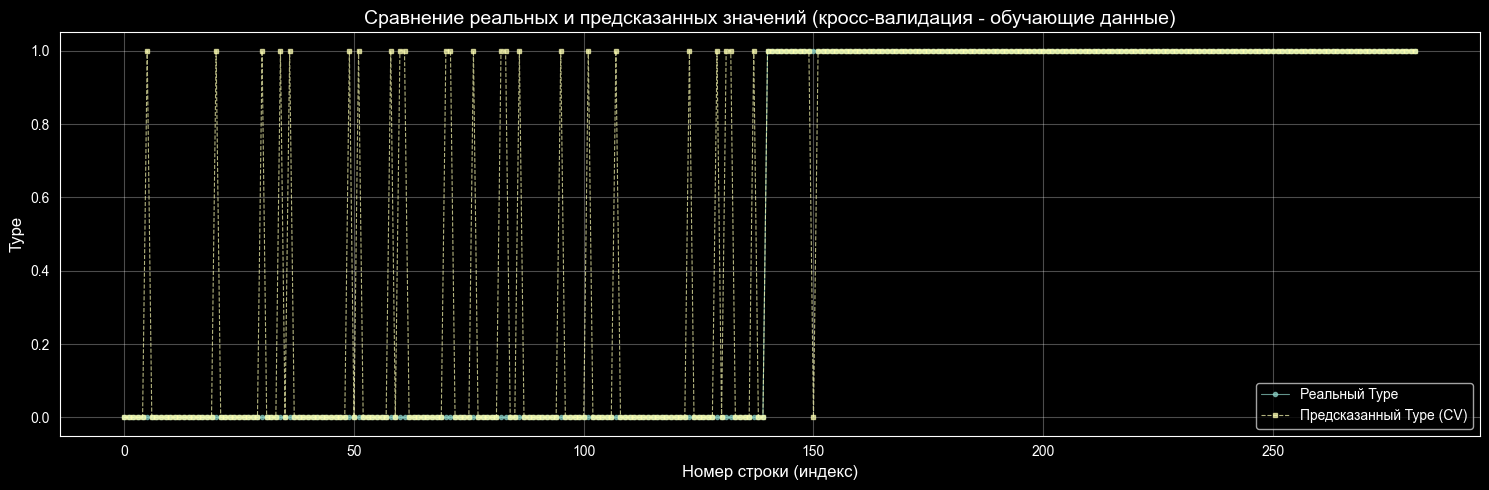

In [83]:
# Строится модель
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score,f1_score, classification_report, confusion_matrix
import joblib
from imblearn.over_sampling import SMOTE, ADASYN
from collections import Counter

# Масштабирование данных
scaler = MinMaxScaler()
sampler = ADASYN(random_state=42)
x_train_scaled = scaler.fit_transform(x)
x_train_balanced, y_train_balanced = sampler.fit_resample(x_train_scaled, y)


# Создание и обучение модели MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    max_iter=800,
    random_state=42,
    verbose=False
)

# Кросс-валидация (5 fold'ов)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(mlp, x_train_balanced, y_train_balanced, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(mlp, x_train_balanced, y_train_balanced, cv=cv, scoring='f1')

print(f"\nAccuracy по fold'ам: {np.round(accuracy_scores, 4)}")
print(f"Средняя Accuracy: {accuracy_scores.mean():.4f}")

print(f"\nF1-score по fold'ам: {np.round(f1_scores, 4)}")
print(f"Средний F1-score: {f1_scores.mean():.4f}")

# Получение предсказаний для обучающих данных (кросс-валидация)
y_train_pred_cv = cross_val_predict(mlp, x_train_balanced, y_train_balanced, cv=cv)

# Матрица ошибок для обучающих данных
cm_train = confusion_matrix(y_train_balanced, y_train_pred_cv)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Матрица ошибок (кросс-валидация - обучающие данные)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# График для обучающих данных
plt.figure(figsize=(15, 5))
indices = range(len(y_train_balanced))
plt.plot(indices, y_train_balanced, 'o-', label='Реальный Type', markersize=3, alpha=0.7, linewidth=0.8)
plt.plot(indices, y_train_pred_cv, 's--', label='Предсказанный Type (CV)', markersize=3, alpha=0.7, linewidth=0.8)
plt.xlabel('Номер строки (индекс)', fontsize=12)
plt.ylabel('Type', fontsize=12)
plt.title('Сравнение реальных и предсказанных значений (кросс-валидация - обучающие данные)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Чтение XLSX файла
file_path_new = "Data_Set_C.xlsx"
df_new = pd.read_excel(file_path_new, engine='openpyxl')

df_new['Type'] = df_new['Type'].apply(lambda x: 1 if x == 5 else 0)

# Расчет vx, vy, omega
vx = (4 * (df_new['V3real'] + df_new['V1real']) * np.cos(np.radians(30))) / 15
vy = (4 * (df_new['V3real'] + df_new['V1real']) * np.sin(np.radians(30)) - 4 * df_new['V2real']) / 15
omega = (df_new['V1real'] + df_new['V2real'] + df_new['V3real']) / 6

# Расчет Ix, Iy, Iphi
Ix = (2 * (df_new['I1'] + df_new['I3']) * np.cos(np.radians(30))) / 3
Iphi = (df_new['I1'] + df_new['I2'] + df_new['I3']) / 3
Isum = Ix + Iy + Iphi

Tx = vx / Ix
Ty = vy / Iy
Tz = omega / Iphi

# Добавление рассчитанных параметров в DataFrame
df_new['vx'] = vx
df_new['vy'] = vy
df_new['omega'] = omega
df_new['Ix'] = Ix
df_new['Iy'] = Iy
df_new['Iphi'] = Iphi
df_new['Isum'] = Isum
df_new['Tx'] = Tx
df_new['Ty'] = Ty
df_new['Tz'] = Tz

df_new = df_new.drop(['N1', 'N2', 'N3'], axis=1)

# После расчета параметров сохраняем обучающую таблицу
output_file_train = "C_extended.csv"
df_new.to_csv(output_file_train, index=False, encoding='utf-8')

file_path = "C_extended.csv"
df_new = pd.read_csv(file_path, encoding='utf-8')

print("Названия параметров (колонок):")
print(df.columns.tolist())

In [ ]:
# Отделяем признаки и целевую переменную
x_test = df_new.drop('Type', axis=1)
y_test = df_new['Type']

# Масштабирование тестовых данных (используем тот же scaler!)
# X_test_scaled = scaler.transform(x_test)

# Предсказание на тестовых данных
y_test_pred = mlp.predict(x_test)

# Метрики для тестовых данных
print(f"\nAccuracy на тестовых данных: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1-score на тестовых данных: {f1_score(y_test, y_test_pred):.4f}")

# Матрица ошибок для тестовых данных
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Матрица ошибок (тестовые данные - C_extended.csv)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# График для тестовых данных
plt.figure(figsize=(15, 5))
indices_test = range(len(y_test))
plt.plot(indices_test, y_test, 'o-', label='Реальный Type', markersize=3, alpha=0.7, linewidth=0.8)
plt.plot(indices_test, y_test_pred, 's--', label='Предсказанный Type', markersize=3, alpha=0.7, linewidth=0.8)
plt.xlabel('Номер строки (индекс)', fontsize=12)
plt.ylabel('Type', fontsize=12)
plt.title(f'Сравнение реальных и предсказанных значений (тестовые данные - {len(y_test)} строк)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nКросс-валидация (обучающие данные):")
print(f"  Средняя Accuracy: {accuracy_scores.mean():.4f}")
print(f"  Средний F1-score: {f1_scores.mean():.4f}")

print(f"\nТестовые данные (C_extended.csv):")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  F1-score: {f1_score(y_test, y_test_pred):.4f}")